In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('customer_shopping_behavior.csv')
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [3]:
df[df.isnull()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [5]:
df['Category'].unique()

<ArrowStringArray>
['Clothing', 'Footwear', 'Outerwear', 'Accessories']
Length: 4, dtype: str

In [6]:
df2=df.groupby(['Category','Review Rating']).size()

In [7]:
df2

Category     Review Rating
Accessories  2.5              22
             2.6              48
             2.7              41
             2.8              44
             2.9              46
                              ..
Outerwear    4.6              15
             4.7              12
             4.8               9
             4.9               8
             5.0               6
Length: 104, dtype: int64

In [8]:
df['Review Rating']=df['Review Rating'].fillna(df['Review Rating'].median())

df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [9]:
df.isnull().sum()


Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [10]:
df3=df.groupby(["Discount Applied","Promo Code Used"]).size()

In [11]:
df=df.drop(["Promo Code Used"],axis = 1)


In [12]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

In [13]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='str')

In [14]:
!pip install psycopg2-binary sqlalchemy pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\darkk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
import psycopg2


In [16]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually


In [17]:
# Install required package first
# pip install pandas sqlalchemy psycopg2-binary


from sqlalchemy import create_engine



# PostgreSQL connection details
username = "postgres"
password = "VISU"
host = "localhost"
port = "5432"
database = "cusbdb"

# Create connection engine
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Upload dataframe to PostgreSQL
df.to_sql(
    name="customer_sales",   # table name
    con=engine,
    if_exists="replace",     # replace / append / fail
    index=False
)

print("DataFrame successfully connected and uploaded to PostgreSQL!")

DataFrame successfully connected and uploaded to PostgreSQL!


In [18]:
result=pd.read_sql("select * from customer_sales LIMIT 5",engine)
print(result)

   customer_id  age gender item_purchased  category  purchase_amount_(usd)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        location size      color  season  review_rating subscription_status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   shipping_type discount_applied  previous_purchases pa

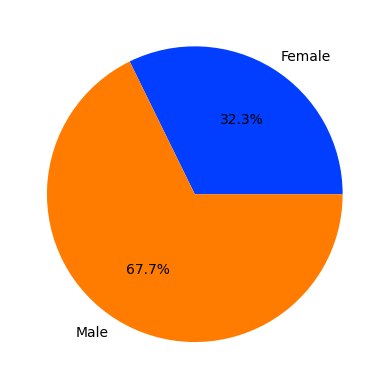

In [42]:
total_revenue = df['purchase_amount_(usd)'].sum()
colors = sns.color_palette('bright')
gender_revenue = df.groupby('gender')['purchase_amount_(usd)'].sum()
plt.pie(gender_revenue, labels=gender_revenue.index, colors=colors, autopct='%1.1f%%')
plt.show()

In [19]:
r1 = pd.read_sql(
    'SELECT item_purchased, SUM("purchase_amount_(usd)") AS total_ '
    'FROM customer_sales '
    'WHERE gender = \'Male\''
    'GROUP BY item_purchased',
    engine
)
r1

,item_purchased,total_
0,Backpack,6223.0
1,Belt,6426.0
2,Blouse,6394.0
3,Boots,5792.0
4,Coat,6428.0
5,Dress,6828.0
6,Gloves,6061.0
7,Handbag,5515.0
8,Hat,6257.0
9,Hoodie,5760.0


In [22]:
r2 = pd.read_sql(
    'SELECT SUM("purchase_amount_(usd)") AS total_ '
    'FROM customer_sales '
    'WHERE "purchase_amount_(usd)" > (SELECT AVG("purchase_amount_(usd)") FROM customer_sales)',
    engine
)
r2

,total_
0,157487.0


Text(0, 0.5, 'Total Amount')

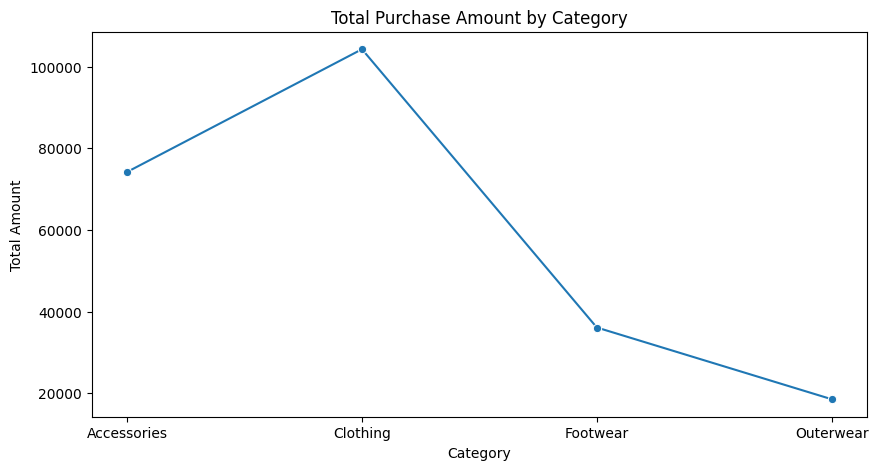

In [50]:
plt.figure(figsize=(10,5))

plot_data = df.groupby('category')['purchase_amount_(usd)'].sum().reset_index()
sns.lineplot(
    data=plot_data,
    x='category',
    y='purchase_amount_(usd)',
    marker='o'
)

plt.title('Total Purchase Amount by Category')
plt.xlabel('Category')
plt.ylabel('Total Amount')

In [23]:
r3 = pd.read_sql(
    """
    SELECT item_purchased,
           ROUND(AVG("review_rating")::numeric, 2) AS avrg_
    FROM customer_sales
    GROUP BY item_purchased
    ORDER BY avrg_ DESC
    LIMIT 5
    """,
    engine
)
r3

,item_purchased,avrg_
0,Gloves,3.86
1,Sandals,3.84
2,Boots,3.82
3,Hat,3.80
4,Skirt,3.79


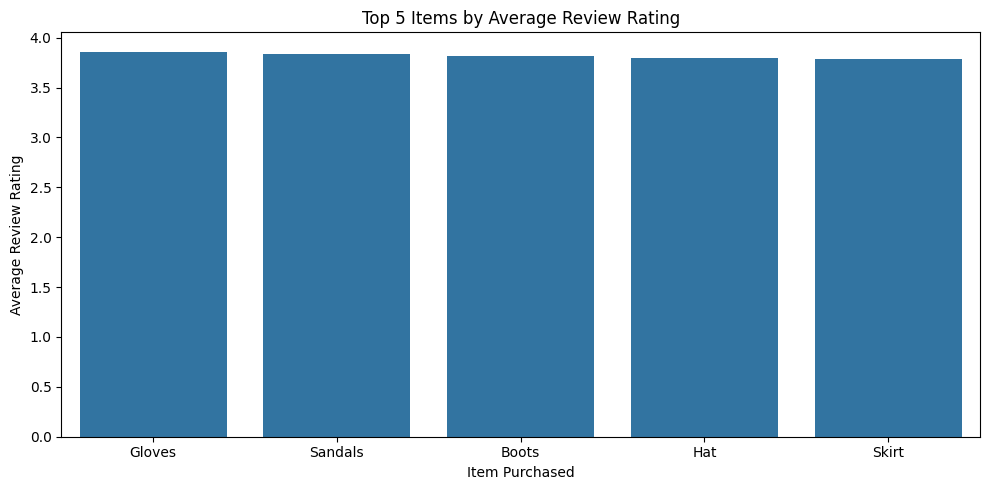

In [52]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=r3,
    x='item_purchased',
    y='avrg_'
)

plt.title('Top 5 Items by Average Review Rating')
plt.xlabel('Item Purchased')
plt.ylabel('Average Review Rating')
plt.tight_layout()
plt.show()

In [58]:
r4 = pd.read_sql(
    """
    SELECT shipping_type, ROUND(AVG("purchase_amount_(usd)")::numeric,2) AS avg_purchase
    FROM customer_sales
    WHERE shipping_type IN ('Express','Standard')
    GROUP BY shipping_type
    """,engine
)
r4

,shipping_type,avg_purchase
0,Standard,58.46
1,Express,60.48


Text(0, 0.5, 'Shipping Type')

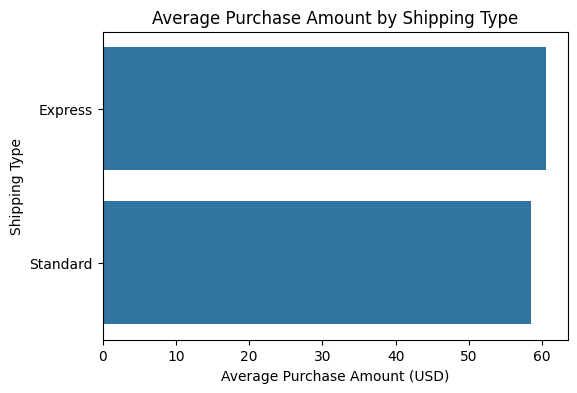

In [57]:
plt.figure(figsize=(6,4))
shipping_avg = (
    df[df['shipping_type'].isin(['Express', 'Standard'])]
    .groupby('shipping_type')['purchase_amount_(usd)']
    .mean()
    .reset_index(name='avg_purchase')
)

sns.barplot(
    data=shipping_avg,
    y='shipping_type',
    x='avg_purchase'
)

plt.title('Average Purchase Amount by Shipping Type')
plt.xlabel('Average Purchase Amount (USD)')
plt.ylabel('Shipping Type')

In [25]:
r4 = pd.read_sql(
    """
    SELECT subscription_status, ROUND(AVG("purchase_amount_(usd)")::numeric,2) AS avg_purchase,SUM("purchase_amount_(usd)") AS total_revene
    FROM customer_sales
    GROUP BY subscription_status
    """,engine
)
r4

,subscription_status,avg_purchase,total_revene
0,No,59.87,170436.0
1,Yes,59.49,62645.0


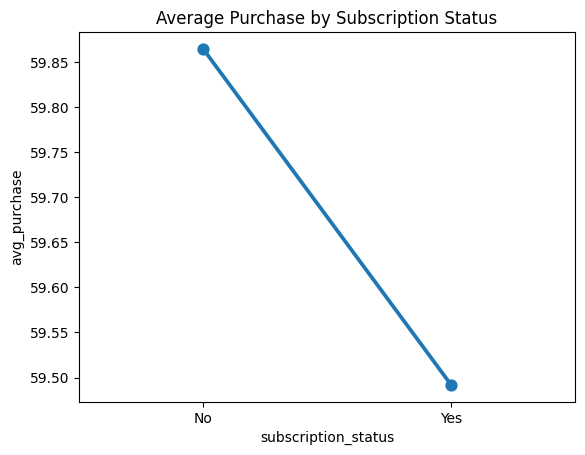

In [63]:
subscription_avg = (
    df.groupby('subscription_status')['purchase_amount_(usd)']
      .mean()
      .reset_index(name='avg_purchase')
)

sns.pointplot(
    data=subscription_avg,
    x='subscription_status',
    y='avg_purchase'
)

plt.title('Average Purchase by Subscription Status')
plt.show()

In [26]:
r5 = pd.read_sql(
    """
    SELECT item_purchased,
           ROUND(100.0 * SUM(CASE WHEN discount_applied = 'Yes' THEN 1 ELSE 0 END) / COUNT(*)::numeric, 2) AS discount_percentage
    FROM customer_sales
    GROUP BY item_purchased
    ORDER BY discount_percentage DESC
    LIMIT 5
    """,
    engine
)
r5

,item_purchased,discount_percentage
0,Hat,50.00
1,Sneakers,49.66
2,Coat,49.07
3,Sweater,48.17
4,Pants,47.37


C:\Users\darkk\AppData\Local\Temp\ipykernel_22092\2574160988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


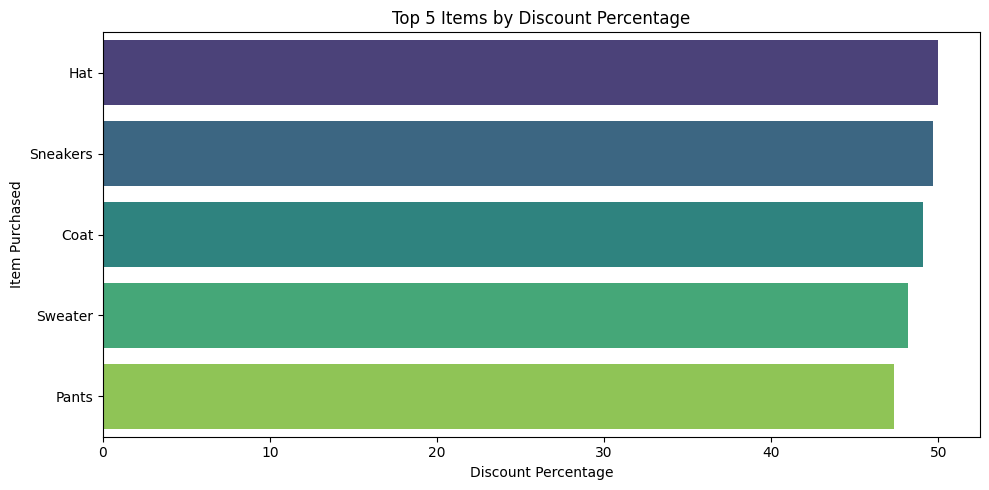

In [64]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=r5,
    x='discount_percentage',
    y='item_purchased',
    palette='viridis'
)
plt.title('Top 5 Items by Discount Percentage')
plt.xlabel('Discount Percentage')
plt.ylabel('Item Purchased')
plt.tight_layout()
plt.show()

In [31]:
r6 = pd.read_sql("""
  SELECT
    CASE
      WHEN previous_purchases = 0 THEN 'New'
      WHEN previous_purchases BETWEEN 1 AND 2 THEN 'Returning'
      ELSE 'Loyal'
    END AS customer_segment,
    COUNT(*) AS segment_count
  FROM customer_sales
  GROUP BY
    CASE
      WHEN previous_purchases = 0 THEN 'New'
      WHEN previous_purchases BETWEEN 1 AND 2 THEN 'Returning'
      ELSE 'Loyal'
    END
  """, engine)
r6
r6

,customer_segment,segment_count
0,Loyal,3745
1,Returning,155


C:\Users\darkk\AppData\Local\Temp\ipykernel_22092\1798782808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


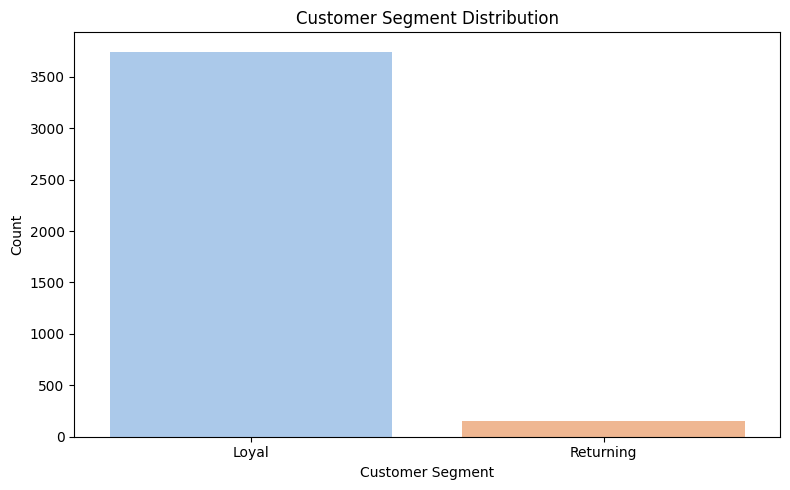

In [65]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=r6,
    x='customer_segment',
    y='segment_count',
    palette='pastel'
)
plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [33]:
r7 = pd.read_sql(
  """
  WITH product_counts AS (
    SELECT
    category,
    item_purchased,
    COUNT(*) AS purchase_count
    FROM customer_sales
    GROUP BY category, item_purchased
  )
  SELECT
    category,
    item_purchased,
    purchase_count
  FROM (
    SELECT
    category,
    item_purchased,
    purchase_count,
    ROW_NUMBER() OVER (PARTITION BY category ORDER BY purchase_count DESC) AS rn
    FROM product_counts
  ) x
  WHERE rn <= 3
  ORDER BY category, purchase_count DESC;
  """,
  engine
)
r7

,category,item_purchased,purchase_count
0,Accessories,Jewelry,171
1,Accessories,Sunglasses,161
2,Accessories,Belt,161
3,Clothing,Blouse,171
4,Clothing,Pants,171
5,Clothing,Shirt,169
6,Footwear,Sandals,160
7,Footwear,Shoes,150
8,Footwear,Sneakers,145
9,Outerwear,Jacket,163


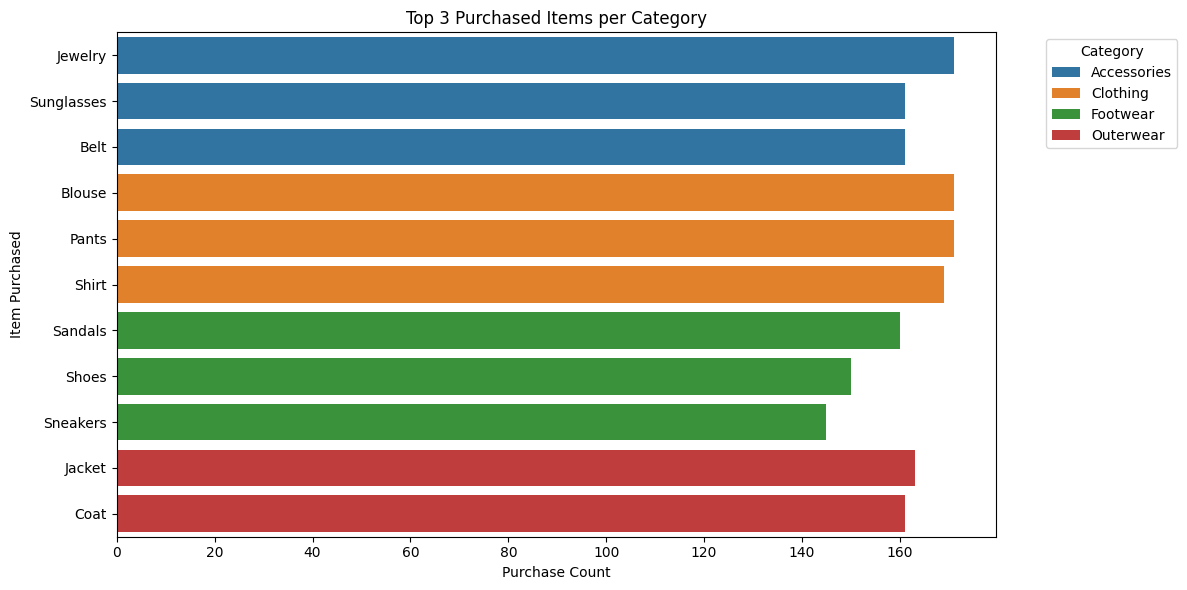

In [66]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=r7,
    x='purchase_count',
    y='item_purchased',
    hue='category',
    dodge=False,
    palette='tab10'
)
plt.title('Top 3 Purchased Items per Category')
plt.xlabel('Purchase Count')
plt.ylabel('Item Purchased')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [35]:
r8 = pd.read_sql(
  """
  WITH product_counts AS (
    SELECT
    category,
    item_purchased,
    COUNT(*) AS purchase_count
    FROM customer_sales
    GROUP BY category, item_purchased
  )
  SELECT
    category,
    item_purchased,
    purchase_count
  FROM (
    SELECT
    category,
    item_purchased,
    purchase_count,
    ROW_NUMBER() OVER (PARTITION BY category ORDER BY purchase_count DESC) AS rn
    FROM product_counts
  ) x
  WHERE rn <= 3
  ORDER BY category, purchase_count DESC;
  """,
  engine
)
r8 

,category,item_purchased,purchase_count
0,Accessories,Jewelry,171
1,Accessories,Sunglasses,161
2,Accessories,Belt,161
3,Clothing,Blouse,171
4,Clothing,Pants,171
5,Clothing,Shirt,169
6,Footwear,Sandals,160
7,Footwear,Shoes,150
8,Footwear,Sneakers,145
9,Outerwear,Jacket,163


<Figure size 1200x600 with 0 Axes>

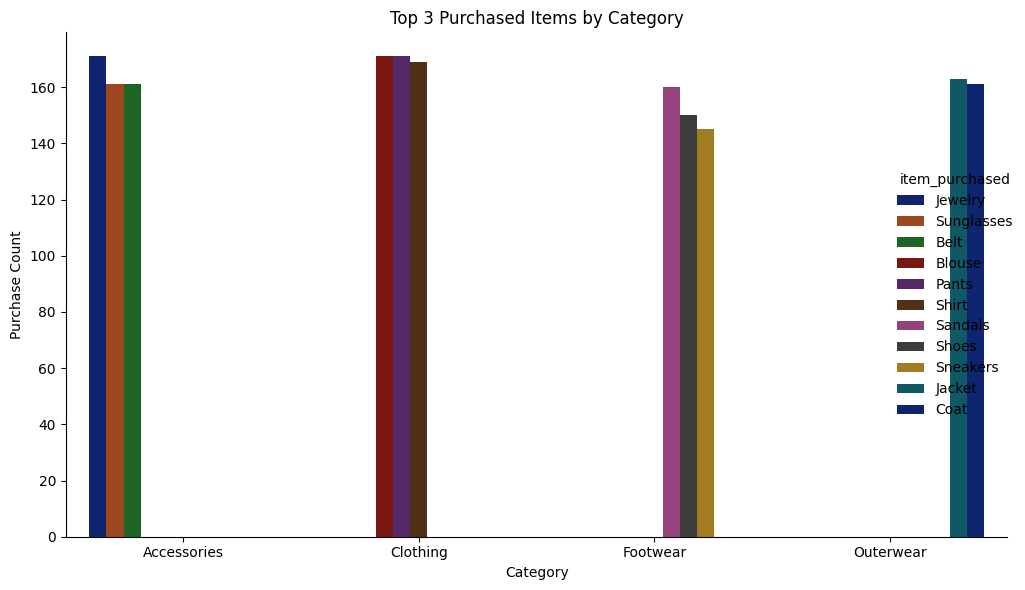

In [67]:
plt.figure(figsize=(12, 6))
sns.catplot(
    data=r8,
    x='category',
    y='purchase_count',
    hue='item_purchased',
    kind='bar',
    height=6,
    aspect=1.5,
    palette='dark'
)
plt.title('Top 3 Purchased Items by Category')
plt.xlabel('Category')
plt.ylabel('Purchase Count')
plt.tight_layout()
plt.show()